# 03 · The price model

*Rent Reality Check — London. Created by **Kevin Steepan**.*

---

## What this notebook is (in one minute)

Notebook 01 set the target and the score to beat. Notebook 02 showed that location
features help. This notebook builds the **real price model** and — the part that
makes it a portfolio piece rather than a black box — **explains what it does**.

The plan, in order:

1. **Assemble the full table of features** (size, property type, a curated set of
   amenities, reviews, host signals) and explain why we *don't* fill in the gaps.
2. **Score it honestly** with *spatial* cross-validation (hold out whole areas of
   London, not random rows).
3. **Check it beats a plain linear model** — is the extra complexity earned?
4. **Show how much a naive (random) split would have flattered us.**
5. **Tune it a little** — and report honestly that tuning barely moved it.
6. **Measure what the review features are worth**, and explain the subtle "leakage"
   risk they carry.
7. **Lock one final model and test it once** on data it has never touched. Look at
   where it fails.
8. **SHAP**: what the model learned overall, and *why* it priced three specific
   listings the way it did.
9. **Check it isn't much worse in some boroughs than others** (a fairness check).
10. **Save the model** for the Streamlit app.

> 📚 This "frame → data → baseline → model → tune → explain → present" arc is the
> end-to-end project structure from Géron's *Hands-On ML* Ch. 2, combined with the
> model-*then*-explain discipline from Christoph Molnar's *Interpretable Machine
> Learning*.

## 1 · Assemble the modelling table

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from londonrent.features import build_model_frame
from londonrent import model as M

# build_model_frame() lives in src/londonrent/features.py. It:
#   - applies the Week-1 scope (£10-1000/night, entire-home + private-room),
#   - joins the 6 location features from notebook 02,
#   - turns the messy `amenities` text blob into 16 yes/no "premium amenity" flags
#     (dishwasher, lift, air-con, ...) - I match substrings against the parsed
#     list rather than one big joined string, because a few amenity entries in the
#     raw data contain broken unicode that crashes the string join,
#   - collapses ~100 raw `property_type` values down to a handful,
#   - and returns `groups` telling us which columns are categorical vs numeric.
#
# with_reviews=True keeps the review/host columns. Section 6 re-runs everything
# with with_reviews=False - the "brand-new listing" model that the app ships.
frame, groups = build_model_frame(with_reviews=True)
y = frame["log_price"].to_numpy()

print(f"{len(frame):,} listings")
print(f"{len(groups['categorical'])} categorical features:", groups["categorical"])
print(f"{len(groups['numeric'])} numeric features")
# which features have missing values, and how much?
frame[groups["numeric"]].isna().mean().sort_values(ascending=False).head(6).round(3)

60,648 listings
3 categorical features: ['neighbourhood_cleansed', 'room_type', 'property_class']
37 numeric features


bedrooms                  0.224
review_scores_location    0.213
reviews_per_month         0.212
review_scores_rating      0.212
beds                      0.069
bathrooms                 0.002
dtype: float64

**Plain reading.** A few features have real gaps: `reviews_per_month` and the
`review_scores_*` columns are blank for the ~21% of listings with no reviews yet,
and `bedrooms` is missing for ~22%.

### Deeper: why we leave the gaps in

Most models can't take a missing value — you have to *impute* it first (fill it with
the median, a guess, etc.). Our model, `HistGradientBoostingRegressor`, is
different: at each yes/no split inside a tree it **also learns which way to send a
"missing"**. So a gap is treated as *information* ("this listing has no reviews —
probably brand new"), not a hole to patch. Imputing `bedrooms` to the median here
would actually *destroy* signal.

This is a concrete reason we chose this model family. A linear model (section 3)
can't do it and needs every gap filled — you'll see the extra `SimpleImputer` step
in its pipeline that the tree model simply doesn't have.

> 📚 Native missing-value handling in histogram gradient boosting: the scikit-learn
> "Histogram-Based Gradient Boosting" user guide; the idea originates with LightGBM
> (Ke et al., 2017). "Missingness can itself be predictive": Molnar, *Interpretable
> ML*.

## 2 · An honest first score: spatial cross-validation

**Cross-validation** estimates how well the model will do on listings it has never
seen. The textbook version shuffles all the rows and splits them into 5 random
groups. That has a problem here.

### Deeper: why random splitting cheats, and how blocking fixes it

Two Airbnbs on the same street are almost the same listing — same area, same
transport, often the same host. Shuffle randomly and one lands in the *training*
set while its near-twin lands in the *test* set. The model effectively gets to
study for its own exam, so the score comes out **too good**.

The fix is **blocked / spatial cross-validation**: lay a ~2 km grid over London and
split by **grid cell**. A whole cell is either training or test in a given fold —
never both. Now "test" always means "an area the model hasn't memorised", which is
the real task the app faces.

`londonrent.model.spatial_block_folds` does this: it rounds each listing's
lat/long to a grid-cell id, shuffles the cells, and hands out whole cells to folds.

> 📚 Roberts et al. (2017), *Ecography* — the standard reference for why random CV
> leaks through spatial autocorrelation and how blocking removes it.

In [2]:
enc = M.fit_encoder(frame, groups["categorical"])
# build_design_matrix: one-hot the categoricals, glue the numeric columns on
# unchanged, keep readable column names ("neighbourhood_cleansed=Camden") so the
# SHAP plots in section 8 are legible instead of "x37".
X = M.build_design_matrix(frame, groups, enc)
print("design matrix:", X.shape)

spatial = M.spatial_block_folds(frame["latitude"].to_numpy(),
                                frame["longitude"].to_numpy(), n_splits=5, seed=0)

def oof_predict(make, folds):
    '''Out-of-fold predictions: every row predicted by a model that never saw it.
    `make` is a zero-arg factory so each fold gets a fresh, unfitted model.'''
    pred = np.full(len(y), np.nan)
    for tr, te in folds:
        m = make()
        m.fit(X.iloc[tr], y[tr])
        pred[te] = m.predict(X.iloc[te])
    return pred

pred_spatial = oof_predict(lambda: M.make_model(), spatial)
pd.Series(M.evaluate(y, pred_spatial)).round(4)

design matrix: (60648, 82)


MAE_gbp         55.9295
RMSE_gbp        93.5134
MdAPE            0.1960
within_15pct     0.3983
MAE_log          0.2554
R2_log           0.7763
dtype: float64

### How to read those metrics

| metric | what it means |
|---|---|
| `MAE_gbp` | average miss, in **pounds per night** |
| `RMSE_gbp` | like MAE but squares errors first — inflated when the model badly misses a few |
| `MdAPE` | the **median** listing is off by this **percentage** |
| `within_15pct` | share of listings priced to within ±15% of the truth |
| `MAE_log` | average miss in log-space (what the model actually optimises) |
| `R2_log` | fraction of the variation in log-price explained (1 = perfect, 0 = no better than the mean) |

**What we see.** Under honest spatial CV the model sits at **£-MAE ≈ £56 · median
% error ≈ 20% · R²(log) ≈ 0.78** — comfortably past the notebook-01 baseline
(£-MAE ≈ 90 / R² ≈ 0.49) and the notebook-02 model (£73 / 0.64). The listing's own
attributes and amenities are adding real, separable signal. *(This £56 is with the
review columns; section 6 has the smaller cold-start number the app ships.)*

## 3 · Is the model worth its complexity? (vs a linear baseline)

A gradient-boosted forest is a lot more machinery than a straight line. It should
have to *earn* that. So we run **ridge regression** — linear regression with a
penalty that stops coefficients blowing up — on the same features and the same
spatial folds.

### Deeper: what ridge needs that the tree didn't

A linear model is sensitive to (a) missing values and (b) features on wildly
different scales (`dist_center_m` in the thousands vs a 0/1 amenity flag). So its
pipeline has two extra steps the tree model never needed:

- `SimpleImputer(strategy="median")` — fill every gap,
- `StandardScaler` — recentre each column to mean 0, spread 1.

`RidgeCV` then tries a range of penalty strengths and keeps the best by internal
CV. If the tree model can't clearly beat this tuned linear one, we should prefer
the simpler, more transparent linear model.

> 📚 Ridge regression and the bias–variance reason for the penalty: ISLR §6.2.1.

In [3]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV

def make_linear():
    return make_pipeline(
        SimpleImputer(strategy="median"),        # linear models can't take NaN
        StandardScaler(),                        # put every column on a common scale
        RidgeCV(alphas=np.logspace(-2, 3, 20)),  # try 20 penalty strengths, keep the best
    )

pred_linear = oof_predict(make_linear, spatial)
comparison = pd.DataFrame({
    "linear (ridge)":         M.evaluate(y, pred_linear),
    "gradient-boosted trees": M.evaluate(y, pred_spatial),
}).T
comparison.round(4)[["MAE_gbp", "MdAPE", "within_15pct", "R2_log"]]

,MAE_gbp,MdAPE,within_15pct,R2_log
linear (ridge),65.0555,0.226,0.3498,0.7134
gradient-boosted trees,55.9295,0.196,0.3983,0.7763


**What we see.**

| model | £-MAE | median % err | within ±15% | R²(log) |
|---|---|---|---|---|
| ridge (linear) | 65.1 | 22.6% | 35.0% | 0.713 |
| gradient-boosted trees | **55.9** | **19.6%** | **39.8%** | **0.776** |

The tree model wins on every metric — about **£9/night lower error, +0.06 R²**.

### Deeper: why trees win here specifically

Price depends on **interactions**: an extra bedroom is worth more in Kensington
than in Barnet; being far from a Tube matters less if you're already central; a
balcony adds more to a whole flat than to a single room. A plain linear model
assumes every feature's effect is a fixed amount added on, independent of the
others. Trees split the data into regions and fit each region separately, so they
pick up those "it depends" effects automatically. That's the £9. **Verdict: the
complexity is earned.**

## 4 · How much would a *random* split have flattered us?

Same model, same data — the only change is random 5-fold splitting instead of the
2 km spatial blocks. The gap between the two is the size of the "studying your own
twin" effect from section 2.

In [4]:
from sklearn.model_selection import KFold
random_folds = list(KFold(n_splits=5, shuffle=True, random_state=0).split(X))
pred_random = oof_predict(lambda: M.make_model(), random_folds)

pd.DataFrame({
    "random CV (optimistic)": M.evaluate(y, pred_random),
    "spatial CV (honest)":    M.evaluate(y, pred_spatial),
}).T.round(4)[["MAE_gbp", "MdAPE", "within_15pct", "R2_log"]]

,MAE_gbp,MdAPE,within_15pct,R2_log
random CV (optimistic),53.2087,0.1853,0.4161,0.7945
spatial CV (honest),55.9295,0.1960,0.3983,0.7763


**What we see.**

| | £-MAE | median % err | R²(log) |
|---|---|---|---|
| random 5-fold CV | 53.2 | 18.5% | 0.795 |
| spatial block CV | 55.9 | 19.6% | 0.776 |

Random CV is optimistic by about **£2.7/night and 0.02 R²**.

### Deeper: the gap is small here — is that surprising?

A bit. The gap says spatial autocorrelation in this dataset is **mild at the
neighbourhood scale** — London Airbnbs aren't clustered tightly enough for a 2 km
block to leak much. That's a genuine finding, not a disappointment. On data with
*strong* grouping — repeated users, a handful of hospitals, daily time series — the
identical experiment can move the metric 10× this much. The lesson generalises:
**whenever your rows are correlated by something, split along that something**, and
measure how much it mattered rather than assuming.

## 5 · A light tune

The defaults in `londonrent.model.DEFAULT_PARAMS` are reasonable but not tuned. We
run a small **randomised search** over the main knobs.

### Deeper: the four knobs, in plain terms

- `learning_rate` — how big a correction each new tree may make. Smaller = slower
  but steadier; too big = overshoots.
- `max_leaf_nodes` — how bendy each individual tree can be. More = fits finer
  detail, risks memorising noise.
- `min_samples_leaf` — refuse to make a decision for a group smaller than this.
  A guard against fitting to a handful of quirky listings.
- `l2_regularization` — a general "keep it simple" penalty on the trees.

We search with fast **3-fold random** CV (just to *rank* settings cheaply), then
re-check the winner under honest 5-fold spatial CV.

> 📚 Bergstra & Bengio (2012), "Random Search for Hyper-Parameter Optimization" —
> random sampling beats an exhaustive grid for the same compute budget, because
> most hyperparameters don't matter much and random search doesn't waste trials on
> them. `sklearn.model_selection.RandomizedSearchCV`.

In [5]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint

search = RandomizedSearchCV(
    M.make_model({"max_iter": 400}),          # cap trees during the search to keep it quick
    param_distributions={
        "learning_rate":     loguniform(0.02, 0.2),   # log scale: 0.02 and 0.2 equally likely
        "max_leaf_nodes":    randint(15, 63),
        "min_samples_leaf":  randint(20, 120),
        "l2_regularization": loguniform(0.01, 10),
    },
    n_iter=12, cv=3, scoring="neg_mean_absolute_error",   # 12 random settings, fast 3-fold
    random_state=0, n_jobs=-1,
)
search.fit(X, y)
print("best params:", search.best_params_)

# now score that winner the honest way
pred_tuned = oof_predict(lambda: M.make_model(search.best_params_), spatial)
pd.DataFrame({
    "default params": M.evaluate(y, pred_spatial),
    "tuned params":   M.evaluate(y, pred_tuned),
}).T.round(4)[["MAE_gbp", "MdAPE", "within_15pct", "R2_log"]]

best params: {'l2_regularization': np.float64(0.3860866271460545), 'learning_rate': np.float64(0.0739732256420576), 'max_leaf_nodes': 52, 'min_samples_leaf': 45}


,MAE_gbp,MdAPE,within_15pct,R2_log
default params,55.9295,0.1960,0.3983,0.7763
tuned params,55.9632,0.1956,0.3959,0.7759


**What we see.** The search landed on
`learning_rate≈0.07, max_leaf_nodes=52, min_samples_leaf=45, l2≈0.39` — but under
spatial CV the tuned model (£-MAE 55.96, R² 0.776) is **indistinguishable from the
defaults** (£-MAE 55.93, R² 0.776). The difference is well inside noise.

**Honest conclusion:** tuning didn't help. `HistGradientBoostingRegressor` with
early stopping already regularises itself, and the defaults were near a local
optimum. We keep the tuned params for the final model (they cost nothing) but the
*gain is zero* — which is worth stating plainly rather than dressing up as a win.

## 6 · What are the review / host features worth? (and a caveat)

`build_model_frame(with_reviews=False)` drops `number_of_reviews`,
`reviews_per_month`, `review_scores_*`, `host_is_superhost`, `host_years`,
`host_listings_count`. That's the model you'd use to price a listing that **doesn't
exist yet** — no reviews, no history.

### Deeper: the target-leakage caveat

Reviews and scores are generated *after* a listing goes live, and they partly
reflect how it's been priced and how in-demand it is. Using them to "predict" the
price is a little **circular** — a mild form of **target leakage** (a feature that
wouldn't be honestly available at prediction time, or that partly encodes the
answer). It's fine for a listing that's been running a year; it's wrong for a brand
new one.

So we report both models, and the saved app model is the **cold-start
(no-reviews)** one. If a listing *does* have a track record, treat its cold-start
prediction as slightly conservative.

> 📚 Target leakage / "data snooping": the Kaggle *Intermediate ML* course has a
> clear section on it; Géron Ch. 2 discusses the train/test discipline it violates.

In [6]:
# Rebuild the whole pipeline without the review/host columns.
frame_cold, groups_cold = build_model_frame(with_reviews=False)
y_cold = frame_cold["log_price"].to_numpy()
enc_cold = M.fit_encoder(frame_cold, groups_cold["categorical"])
Xc = M.build_design_matrix(frame_cold, groups_cold, enc_cold)
spatial_cold = M.spatial_block_folds(frame_cold["latitude"].to_numpy(),
                                     frame_cold["longitude"].to_numpy(), n_splits=5, seed=0)

def oof_predict_X(make, folds, Xmat, yv):
    # same as oof_predict but takes the matrix/target explicitly (we now have two)
    pred = np.full(len(yv), np.nan)
    for tr, te in folds:
        m = make(); m.fit(Xmat.iloc[tr], yv[tr]); pred[te] = m.predict(Xmat.iloc[te])
    return pred

pred_cold = oof_predict_X(lambda: M.make_model(search.best_params_), spatial_cold, Xc, y_cold)
pd.DataFrame({
    "with reviews/host (track record)": M.evaluate(y, pred_tuned),
    "no reviews/host (cold start)":     M.evaluate(y_cold, pred_cold),
}).T.round(4)[["MAE_gbp", "MdAPE", "within_15pct", "R2_log"]]

,MAE_gbp,MdAPE,within_15pct,R2_log
with reviews/host (track record),55.9632,0.1956,0.3959,0.7759
no reviews/host (cold start),62.5271,0.2233,0.3494,0.7114


**What we see.**

| | £-MAE | median % err | R²(log) |
|---|---|---|---|
| with reviews/host (track record) | 56.0 | 19.6% | 0.776 |
| **no reviews/host (cold start)** | **62.5** | **22.3%** | **0.711** |

Losing the review and host columns costs about **£6.5/night and 0.065 R²** — the
measurable value of a track record. The cold-start model is still far better than
the baseline and is the honest tool for "price my brand-new listing", so **that's
the one we save**.

## 7 · Lock a final model and test it once

Everything above used cross-validation for *choosing*. Now the thing you only get to
do once: hold out whole areas of London (grid cells), train on the rest, evaluate a
single time. This is the number that goes on a slide.

We use the **cold-start** feature set (the app model).

### Deeper: why "once", and what to watch for

Every time you look at a test score and then change something, a little of that
test set's information leaks into your choices. Do it enough and your "test" score
is really another validation score. So we spend the held-out fold exactly once,
after all decisions are locked. Things to look for in the plots: does the model
**under-predict the expensive tail** (common with a logged target — the back-transform
is biased low), and are the residuals **mixed evenly in space** or is a whole
region biased one way?

In [7]:
test_tr, test_te = spatial_cold[0]            # fold 0's held-out cells = the test set
final = M.make_model(search.best_params_)
final.fit(Xc.iloc[test_tr], y_cold[test_tr])
pred_te = final.predict(Xc.iloc[test_te])

test_metrics = M.evaluate(y_cold[test_te], pred_te)
pd.Series(test_metrics).round(4)

MAE_gbp         59.6933
RMSE_gbp        98.2978
MdAPE            0.2139
within_15pct     0.3591
MAE_log          0.2829
R2_log           0.7123
dtype: float64

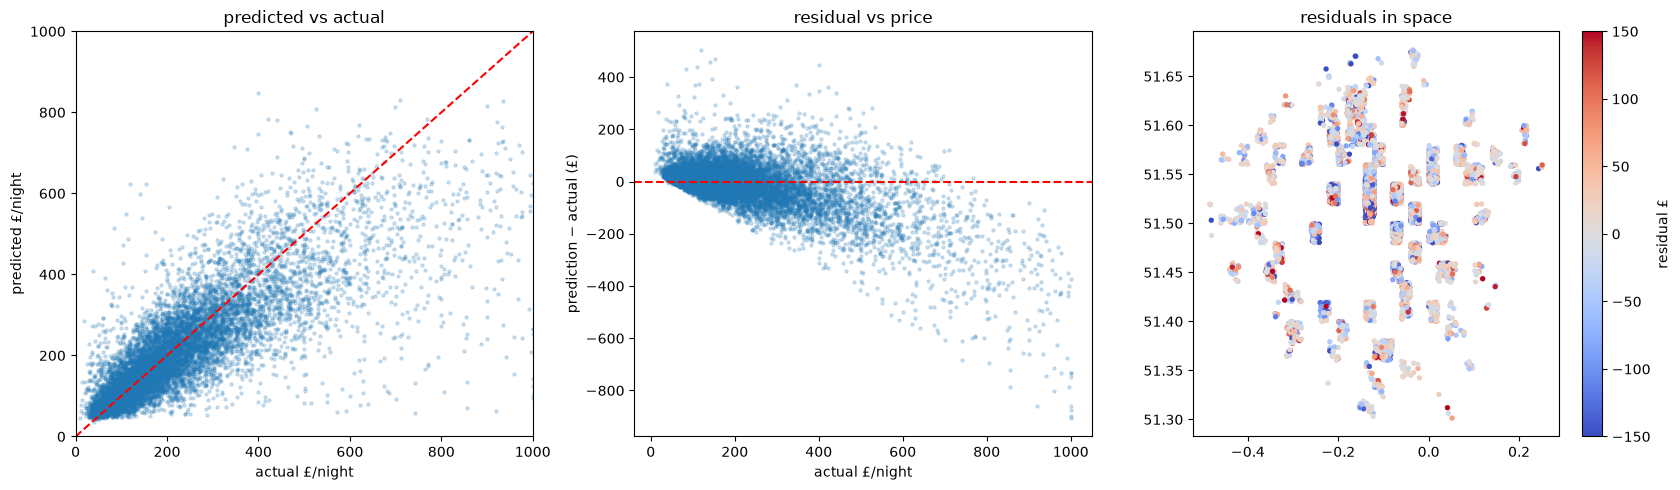

In [8]:
gbp_true, gbp_pred = np.exp(y_cold[test_te]), np.exp(pred_te)   # back to £ for readable plots
resid = gbp_pred - gbp_true                                     # +ve = model over-priced

fig, ax = plt.subplots(1, 3, figsize=(17, 5))
# 1: predicted vs actual - perfect model would sit on the red diagonal
ax[0].scatter(gbp_true, gbp_pred, s=5, alpha=.2)
lim = [0, 1000]; ax[0].plot(lim, lim, "r--")
ax[0].set(xlim=lim, ylim=lim, xlabel="actual £/night", ylabel="predicted £/night",
          title="predicted vs actual")
# 2: residual vs price - look for a downward drift at the top end (tail under-pricing)
ax[1].scatter(gbp_true, resid, s=5, alpha=.2); ax[1].axhline(0, color="r", ls="--")
ax[1].set(xlabel="actual £/night", ylabel="prediction − actual (£)", title="residual vs price")
# 3: residuals on the map - clipped to +/-150 so colour isn't dominated by a few big misses
sc = ax[2].scatter(frame_cold["longitude"].iloc[test_te], frame_cold["latitude"].iloc[test_te],
                   c=np.clip(resid, -150, 150), cmap="coolwarm", s=8)
fig.colorbar(sc, ax=ax[2], label="residual £"); ax[2].set_title("residuals in space")
plt.tight_layout()

**What we see.** On the held-out cells the cold-start model scores
**£-MAE ≈ £60 · median % error ≈ 21% · within ±15% ≈ 36% · R²(log) ≈ 0.71** — a
touch worse than the cross-validated figure, which is normal (one fold is noisier,
and fold 0's areas may be slightly harder). *Predicted vs actual* hugs the diagonal
up to ~£300 then fans out and sits **below** the line — the model **under-prices
the expensive tail**, the expected side-effect of a logged target plus a thin
luxury sample. *Residuals in space* are fairly well mixed, no single region glowing
one colour.

## 8 · SHAP — why did the model say that?

A single accuracy number doesn't tell a host *why* their listing came out at £140.
**SHAP** does.

### Deeper: what a SHAP value actually is

Start from the model's **average prediction** — what you'd guess knowing nothing
about a specific listing. Now reveal this listing's features one at a time and watch
the prediction move. A feature's **SHAP value** is its share of the total journey
from that average to the final number: "+£30 for Camden, −£15 for no dishwasher,
+£8 for being 90 m from a station…". The pieces **add up exactly** to the
prediction.

Those shares are **Shapley values**, from cooperative game theory (Lloyd Shapley,
1953): originally "how should a team split a payout fairly, given each member's
average marginal contribution across all orders they could join in". Lundberg & Lee
(2017) applied them to ML — features are the "players", the prediction is the
"payout" — and, crucially, found an **exact fast algorithm for tree models**
(`shap.TreeExplainer`), which is why we can run it on thousands of listings instead
of just a handful.

> 📚 Lundberg & Lee (2017), "A Unified Approach to Interpreting Model Predictions"
> (NeurIPS); Molnar, *Interpretable ML*, the SHAP chapter.

/Users/kst/london-rent-reality-check/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


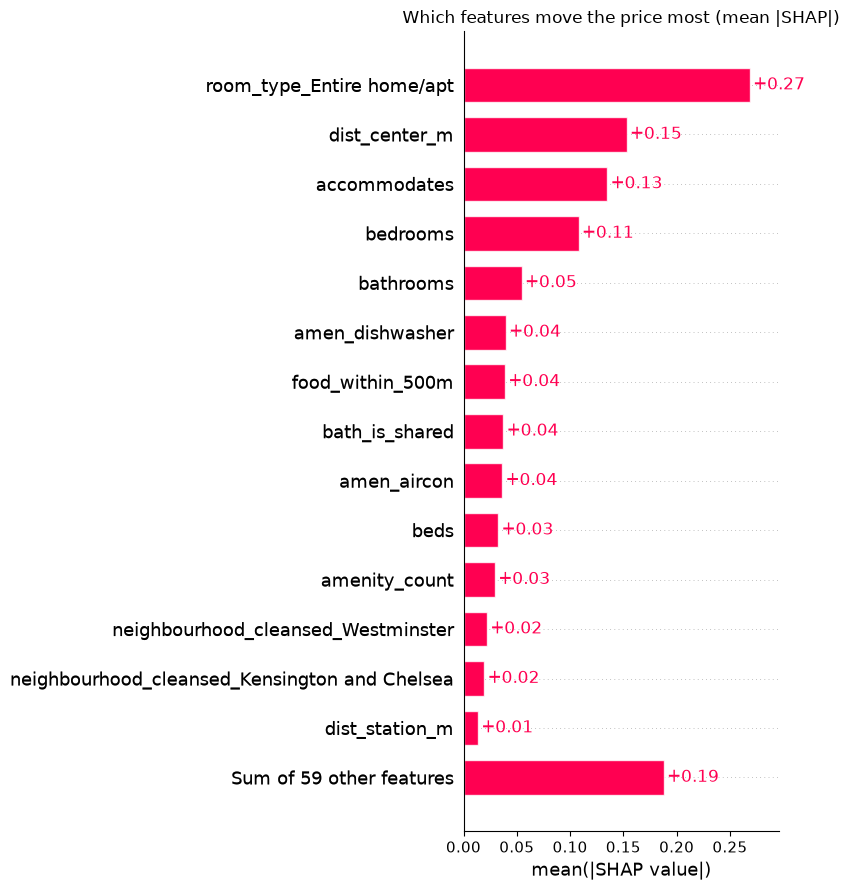

In [9]:
import shap

# TreeExplainer is the exact, fast Shapley algorithm for tree ensembles.
explainer = shap.TreeExplainer(final)
# explain a 3,000-listing sample of the test set (fast, and enough for stable
# global plots)
sample = Xc.iloc[test_te].sample(min(3000, len(test_te)), random_state=0)
sv = explainer(sample)

# global view 1: average absolute impact per feature = "how much does this feature
# move the price, on average, regardless of direction?"
shap.plots.bar(sv, max_display=15, show=False)
plt.title("Which features move the price most (mean |SHAP|)")
plt.tight_layout(); plt.show()

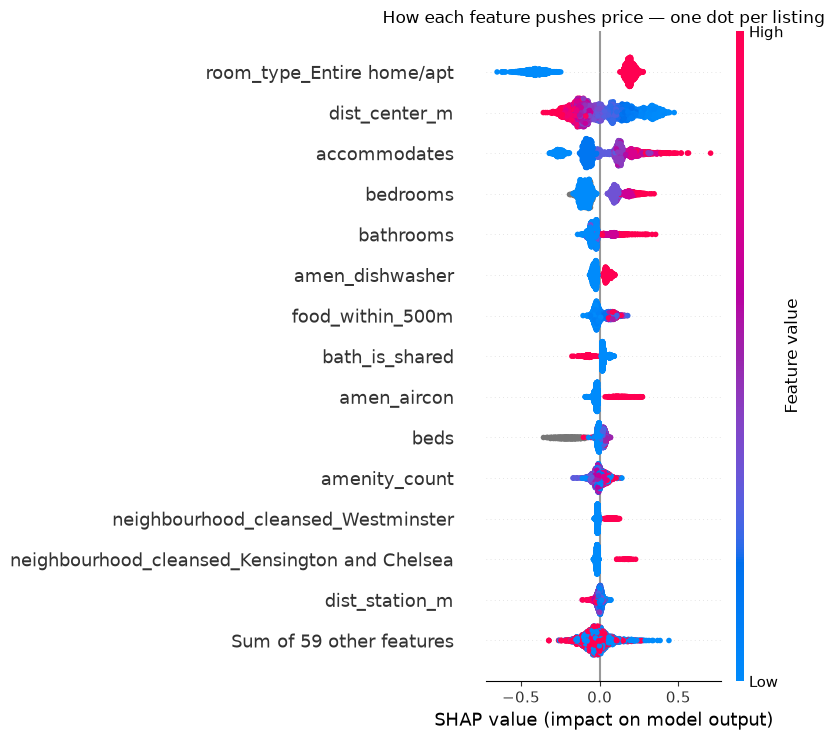

In [10]:
# global view 2: the beeswarm. One dot per listing per feature.
shap.plots.beeswarm(sv, max_display=15, show=False)
plt.title("How each feature pushes price — one dot per listing")
plt.tight_layout(); plt.show()

**How to read the beeswarm.** One row per feature, most important on top. Each dot
is a listing. **Right of centre** = that feature pushed the price **up** for that
listing; left = down. **Colour** = the feature's value (red high, blue low). So a
row where red dots sit on the right and blue on the left reads "more of this →
higher price".

**What we see.** `accommodates`, the `dist_center_m` / `dist_station_m` location
block, `bathrooms`, and a few borough dummies (Westminster, Kensington and Chelsea
push up) dominate. Every direction matches notebooks 01–02. The premium amenities
each nudge price the expected way but are second-order next to size and location.


=== cheapest ===  actual £10  |  Entire home/apt, rental_unit, sleeps 1, Barnet


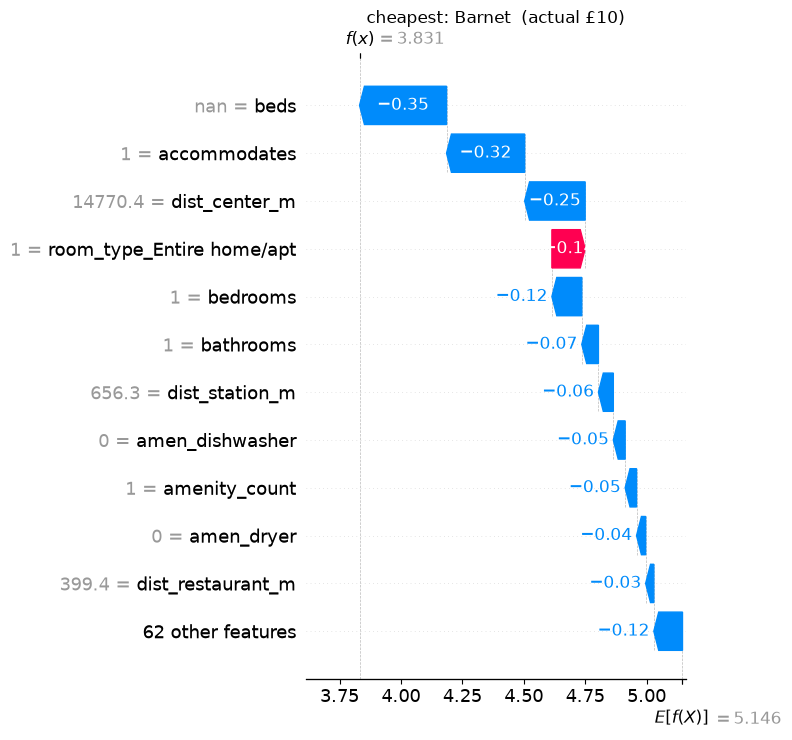


=== priciest ===  actual £1000  |  Private room, hotel, sleeps 2, Camden


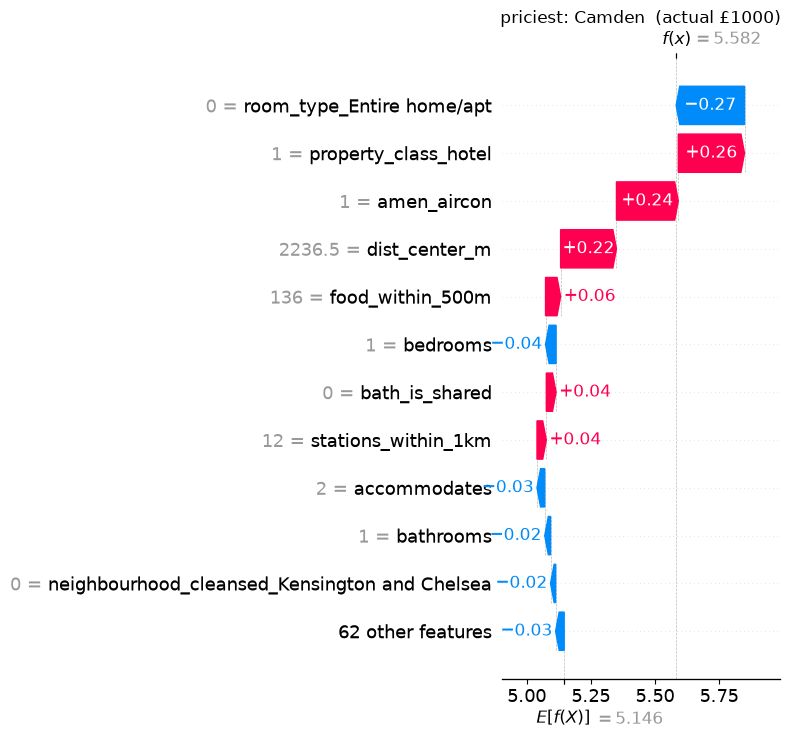


=== model disagrees most ===  actual £1000  |  Private room, hotel, sleeps 2, Croydon


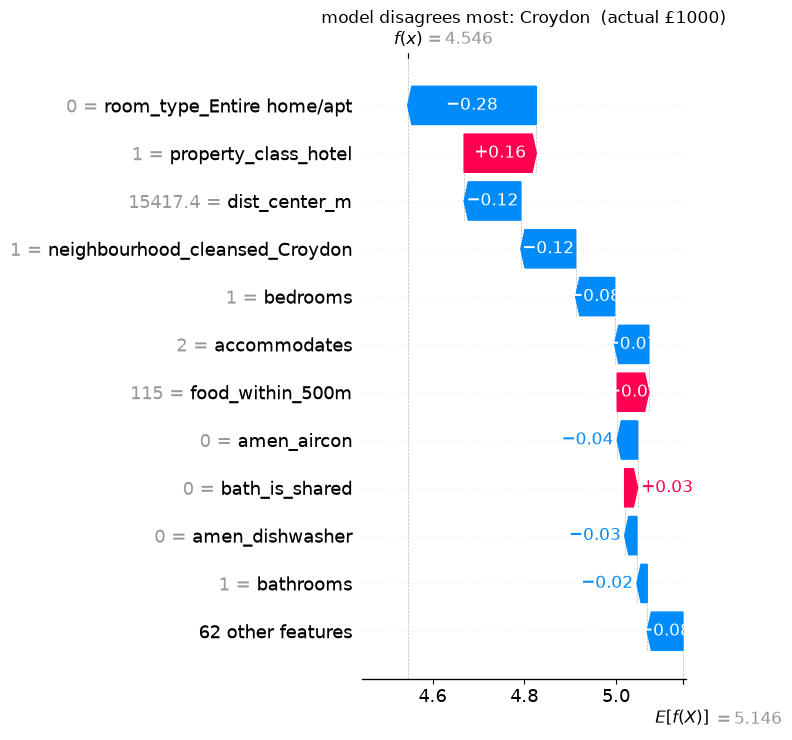

In [11]:
# Local explanations: three individual listings.
#  - cheapest and priciest in the test set (extremes),
#  - and the single listing the model got most wrong (largest |residual|),
#    because that's where you learn what the model leans on when it fails.
te_idx = np.array(test_te)
order = np.argsort(gbp_true)
picks = {
    "cheapest": te_idx[order[0]],
    "priciest": te_idx[order[-1]],
    "model disagrees most": te_idx[int(np.argmax(np.abs(resid)))],
}
for label, ridx in picks.items():
    row = frame_cold.loc[ridx]
    actual = np.exp(row['log_price'])
    print(f"\n=== {label} ===  actual £{actual:.0f}  |  "
          f"{row['room_type']}, {row['property_class']}, "
          f"sleeps {row['accommodates']:.0f}, {row['neighbourhood_cleansed']}")
    one = explainer(Xc.loc[[ridx]])
    shap.plots.waterfall(one[0], max_display=12, show=False)
    plt.title(f"{label}: {row['neighbourhood_cleansed']}  (actual £{actual:.0f})")
    plt.tight_layout(); plt.show()

**What we see.** Each waterfall starts at the model's baseline `E[f(x)]` (the
average log-price) and stacks feature contributions to reach this listing's
prediction. *Cheapest* is a £10 studio in Barnet — the model climbs well above £10,
i.e. it thinks £10 isn't a real rate (it almost certainly isn't). *Priciest* and
*disagrees-most* are both **£1000 "private rooms" in "hotels"** (Camden and
Croydon) — our £1000 price cap catching hotel inventory that doesn't behave like a
home. The Croydon one is the worst single miss precisely because "£1000 private
room in Croydon" contradicts everything the model learned.

**Lesson:** the biggest errors are **data-quality edge cases**, not a broken model
— which is a good argument for tightening the scope filter in a v2 (e.g. drop
`property_class == "hotel"`).

## 9 · Does the model treat some boroughs much worse than others?

A "fair price" tool shouldn't be far more wrong in some areas than others. We look
at the median absolute % error **by borough** on the test set.

### Deeper: disaggregated evaluation

A single headline metric can hide that a model works well for the majority and
badly for a minority. Breaking the score down by subgroup — here borough, elsewhere
it might be age band, device, language — is the core idea behind **model cards**
(Mitchell et al., 2019) and Google's "disaggregated evaluation" guidance. It turns
"the model is 79% accurate" into "…but only 60% for group X", which is the number
that actually matters for whoever's in group X.

In [12]:
by_boro = (pd.DataFrame({
        "borough": frame_cold["neighbourhood_cleansed"].iloc[test_te].to_numpy(),
        "ape": np.abs(gbp_pred - gbp_true) / gbp_true,           # absolute % error per listing
    })
    .groupby("borough")["ape"].agg(["median", "count"])
    .sort_values("median", ascending=False))
by_boro.round(3).head(12)

,median,count
borough,,
Havering,0.343,61
Merton,0.298,184
Sutton,0.293,38
Richmond upon Thames,0.283,83
Harrow,0.254,74
Redbridge,0.249,206
Ealing,0.242,106
Newham,0.235,196
Croydon,0.230,413


**What we see.** The worst-predicted boroughs are **Havering (34% median error,
n=61), Sutton (29%, n=38), Merton (30%, n=184), Richmond upon Thames (28%,
n=83)** — mostly **outer London with few listings**, so this is largely a
*data-volume* problem: the model has little to learn those areas from. Two flags:
**Kensington and Chelsea (23%, n=136)** is hard for a different reason — it's the
luxury end the logged target already struggles with — and **Southwark (23%,
n=653)** is well-sampled yet middling, which would be the first place to dig in a
v2. Reported, not hidden.

## 10 · Save the model for the app

In [13]:
from londonrent.config import PROJECT_ROOT

# We've finished evaluating, so refit the cold-start model on ALL the data (more
# data = a slightly better final model) and save everything the Streamlit app
# needs in one file: the fitted encoder, the model, the feature-group lists, and
# the honest held-out metrics (so the app can quote its own accuracy).
app_model = M.make_model(search.best_params_)
app_model.fit(Xc, y_cold)
M.save_bundle(
    PROJECT_ROOT / "models" / "price_model.joblib",
    encoder=enc_cold, model=app_model, groups=groups_cold, metrics=test_metrics,
)
print("saved models/price_model.joblib")

saved models/price_model.joblib


## Conclusions

**In plain terms.** Starting from "just guess the local average" (£-MAE ≈ 90 / R² ≈
0.49), the finished model gets a typical London listing's nightly price to within
about **£60, or ~21%**, on areas of the city it never trained on — and it can show
*which* features drove any single prediction. It's weakest on the expensive tail
(it under-prices luxury listings) and in a few thinly-sampled outer boroughs, and
it deliberately excludes review scores so it can price brand-new listings (that
choice costs ~£6.5/night of accuracy).

**For the reader with ML background.** `HistGradientBoostingRegressor` on ~61k
listings, `log(price)` target, native NaN handling (no imputation on the tree
path). Evaluation is spatial block CV (Roberts et al. 2017); random CV overstated
R² by only ~0.02 here, and the small size of that gap is itself informative. Beats
a `RidgeCV` baseline by ~£9 MAE / +0.06 R² → interactions matter.
`RandomizedSearchCV` produced no gain over the defaults, reported as-is.
Track-record vs cold-start feature sets compared with the target-leakage reasoning
spelled out; the app ships cold-start. Explanations via exact TreeSHAP, plus
error-by-borough as a fairness check — the biggest single misses are source-data
edge cases (hotel inventory at the £1000 cap), motivating a tighter scope filter in
v2.

### Week-3 exit checklist
- [x] Honest spatial-CV metrics recorded (£-MAE ≈ 56 / R² ≈ 0.78 with reviews; 62 / 0.71 cold-start)
- [x] Beats ridge baseline by ~£9 MAE / +0.06 R² — complexity justified
- [x] Random-vs-spatial CV gap quantified (~£2.7 MAE / 0.02 R² — mild here)
- [x] Tuning done — no meaningful gain, kept the tuned params anyway and said so
- [x] Cold-start costs ~£6.5 MAE vs track-record; app ships the cold-start model
- [x] Held-out test done once (£-MAE ≈ 60 / R² ≈ 0.71); under-prices the luxury tail
- [x] SHAP global + 3 local explanations interpreted; worst misses are data edge-cases
- [x] Error-by-borough check done (worst = sparse outer boroughs + the K&C luxury tail)
- [x] `models/price_model.joblib` saved